In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Sentiment analysis libraries
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [4]:
from scipy.stats import pearsonr, spearmanr

In [5]:
# For progress tracking
from tqdm import tqdm
tqdm.pandas()

In [7]:
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('dark_background')

In [8]:
 # Load Data
import glob
import os

In [10]:
# Load news data
desktop_path = 'C:/Users/hp/Desktop/'
news_file = desktop_path + 'raw_analyst_ratings.csv'

if os.path.exists(news_file):
    news_df = pd.read_csv(news_file)
    print(f"✅ Loaded news data: {len(news_df)} rows")
else:
    # Try project folder
    news_file = 'data/raw/raw_analyst_rating.csv'
    if os.path.exists(news_file):
        news_df = pd.read_csv(news_file)
        print(f"✅ Loaded news data: {len(news_df)} rows")
    else:
        print("❌ News file not found!")
        news_df = None

✅ Loaded news data: 1407328 rows


In [11]:
# Display column names to understand structure
if news_df is not None:
    print(f"\n📋 News data columns: {news_df.columns.tolist()}")
    print(f"\nFirst 3 rows:")
    print(news_df.head(3))


📋 News data columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 3 rows:
   Unnamed: 0                                    headline  \
0           0     Stocks That Hit 52-Week Highs On Friday   
1           1  Stocks That Hit 52-Week Highs On Wednesday   
2           2               71 Biggest Movers From Friday   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00     A  


In [12]:
# Load Stock Data
stock_path = desktop_path + 'yfinance_data/'
stock_files = glob.glob(stock_path + '*.csv')
stock_data = {}

print("Loading stock data...")
for file in stock_files:
    stock_name = os.path.basename(file).replace('.csv', '')
    df = pd.read_csv(file)
    df.columns = df.columns.str.lower()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    stock_data[stock_name] = df
    print(f"✅ Loaded {stock_name}: {len(df)} trading days")

print(f"\n📊 Loaded stocks: {list(stock_data.keys())}")


Loading stock data...
✅ Loaded AAPL: 3774 trading days
✅ Loaded AMZN: 3774 trading days
✅ Loaded GOOG: 3774 trading days
✅ Loaded META: 2923 trading days
✅ Loaded NVDA: 3774 trading days

📊 Loaded stocks: ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']


In [13]:
# Sentiment Analysis on Headlines
vader_analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get VADER sentiment score (-1 to 1)"""
    try:
        scores = vader_analyzer.polarity_scores(str(text))
        return scores['compound']  # Compound score ranges from -1 to 1
    except:
        return 0

def get_textblob_sentiment(text):
    """Get TextBlob sentiment polarity (-1 to 1)"""
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity
    except:
        return 0


In [14]:
# Apply sentiment analysis
if news_df is not None:
    # Find headline column
    headline_col = None
    for col in news_df.columns:
        if 'headline' in col.lower() or 'title' in col.lower() or 'text' in col.lower():
            headline_col = col
            break
    
    if headline_col:
        print(f"📝 Using headline column: '{headline_col}'")
        
        # Calculate sentiments
        print("\nCalculating VADER sentiment scores...")
        news_df['vader_score'] = news_df[headline_col].progress_apply(get_vader_sentiment)
        
        print("Calculating TextBlob sentiment scores...")
        news_df['textblob_score'] = news_df[headline_col].progress_apply(get_textblob_sentiment)
        
        # Classify sentiment categories
        def classify_sentiment(score):
            if score > 0.05:
                return 'Positive'
            elif score < -0.05:
                return 'Negative'
            else:
                return 'Neutral'
        
        news_df['sentiment_class'] = news_df['vader_score'].apply(classify_sentiment)
        
        # Display results
        print("\n📊 Sentiment Analysis Results:")
        print(f"   VADER - Mean: {news_df['vader_score'].mean():.4f}, Std: {news_df['vader_score'].std():.4f}")
        print(f"   TextBlob - Mean: {news_df['textblob_score'].mean():.4f}, Std: {news_df['textblob_score'].std():.4f}")
        
        print("\n📈 Sentiment Distribution:")
        sentiment_counts = news_df['sentiment_class'].value_counts()
        for sentiment, count in sentiment_counts.items():
            print(f"   {sentiment}: {count} ({count/len(news_df)*100:.1f}%)")
    else:
        print("❌ No headline column found!")
        print(f"Available columns: {news_df.columns.tolist()}")


📝 Using headline column: 'headline'

Calculating VADER sentiment scores...


100%|██████████| 1407328/1407328 [06:32<00:00, 3582.97it/s]


Calculating TextBlob sentiment scores...


100%|██████████| 1407328/1407328 [10:33<00:00, 2220.24it/s]



📊 Sentiment Analysis Results:
   VADER - Mean: 0.0669, Std: 0.2723
   TextBlob - Mean: 0.0491, Std: 0.1831

📈 Sentiment Distribution:
   Neutral: 739338 (52.5%)
   Positive: 442930 (31.5%)
   Negative: 225060 (16.0%)


In [15]:
 # Date Alignment and Daily Aggregation
if news_df is not None and headline_col:
    # Convert date column
    date_col = None
    for col in news_df.columns:
        if 'date' in col.lower():
            date_col = col
            break
    
    if date_col:
        news_df['date'] = pd.to_datetime(news_df[date_col], errors='coerce')
        news_df = news_df.dropna(subset=['date'])
        
        # Extract date only (remove time)
        news_df['trade_date'] = news_df['date'].dt.date
        
        # Find stock symbol column
        stock_col = None
        for col in news_df.columns:
            if 'stock' in col.lower() or 'ticker' in col.lower() or 'symbol' in col.lower():
                stock_col = col
                break
        
        if stock_col:
            # Filter to stocks we have price data for
            available_stocks = list(stock_data.keys())
            news_df = news_df[news_df[stock_col].isin(available_stocks)]
            print(f"✅ Filtered to {len(news_df)} articles for available stocks")
            
            # Aggregate daily sentiment by stock
            daily_sentiment = news_df.groupby(['trade_date', stock_col])['vader_score'].agg(['mean', 'count']).reset_index()
            daily_sentiment.columns = ['date', 'stock', 'avg_sentiment', 'article_count']
            
            print(f"\n📅 Daily aggregated sentiment:")
            print(f"   {len(daily_sentiment)} stock-day combinations")
            print(f"   Date range: {daily_sentiment['date'].min()} to {daily_sentiment['date'].max()}")
        else:
            print("❌ No stock column found!")
            daily_sentiment = None
    else:
        print("❌ No date column found!")
        daily_sentiment = None


✅ Filtered to 40 articles for available stocks

📅 Daily aggregated sentiment:
   14 stock-day combinations
   Date range: 2020-05-31 to 2020-06-10


In [16]:
# Calculate Daily Stock Returns
def calculate_returns(df):
    """Calculate daily returns"""
    df = df.copy()
    df['return'] = df['close'].pct_change() * 100  # Percentage change
    df['date_only'] = df['date'].dt.date
    return df[['date_only', 'close', 'return']]

stock_returns = {}
for stock, df in stock_data.items():
    stock_returns[stock] = calculate_returns(df)
    print(f"✅ Calculated returns for {stock}")


✅ Calculated returns for AAPL
✅ Calculated returns for AMZN
✅ Calculated returns for GOOG
✅ Calculated returns for META
✅ Calculated returns for NVDA


In [17]:
# Merge Sentiment with Returns
if daily_sentiment is not None:
    # Create combined dataset
    combined_data = []
    
    for stock in stock_returns.keys():
        # Get returns for this stock
        returns_df = stock_returns[stock].copy()
        returns_df['stock'] = stock
        
        # Get sentiment for this stock
        sentiment_df = daily_sentiment[daily_sentiment['stock'] == stock].copy()
        
        # Merge on date
        merged = pd.merge(
            returns_df, 
            sentiment_df, 
            left_on=['date_only', 'stock'], 
            right_on=['date', 'stock'],
            how='inner'
        )
        
        combined_data.append(merged)
    
    if combined_data:
        combined_df = pd.concat(combined_data, ignore_index=True)
        print(f"✅ Combined dataset: {len(combined_df)} matches")
        print(f"   Columns: {combined_df.columns.tolist()}")
        print(f"\nFirst 5 matches:")
        print(combined_df.head())
    else:
        combined_df = None
        print("❌ No matches found between sentiment and returns")
else:
    combined_df = None
    print("❌ Daily sentiment not available")


✅ Combined dataset: 13 matches
   Columns: ['date_only', 'close', 'return', 'stock', 'date', 'avg_sentiment', 'article_count']

First 5 matches:
    date_only       close    return stock        date  avg_sentiment  \
0  2020-06-09   83.419868  3.157792  AAPL  2020-06-09       0.246900   
1  2020-06-10   85.566071  2.572771  AAPL  2020-06-10       0.198850   
2  2020-06-09  130.042999  3.042714  AMZN  2020-06-09       0.077775   
3  2020-06-10  132.372498  1.791329  AMZN  2020-06-10       0.391233   
4  2020-06-04   70.129089 -1.684800  GOOG  2020-06-04       0.000000   

   article_count  
0              4  
1              6  
2              4  
3              6  
4              1  


In [23]:
# Check data before correlation
print("="*60)
print("DATA CHECK BEFORE CORRELATION")
print("="*60)

# Check if combined_df exists
if 'combined_df' not in locals():
    print("❌ combined_df does not exist!")
else:
    print(f"✅ combined_df exists with {len(combined_df)} rows")
    
    if len(combined_df) == 0:
        print("❌ combined_df is empty!")
    else:
        print(f"\n📊 combined_df info:")
        print(f"   Shape: {combined_df.shape}")
        print(f"   Columns: {combined_df.columns.tolist()}")
        print(f"\n   First 3 rows:")
        print(combined_df.head(3))
        print(f"\n   Last 3 rows:")
        print(combined_df.tail(3))
        
        # Check for missing values
        print(f"\n   Missing values:")
        print(combined_df.isnull().sum())
        
        # Check unique stocks
        print(f"\n   Unique stocks: {combined_df['stock'].unique()}")
        
        # Sample of sentiment and return values
        print(f"\n   Sample sentiment values: {combined_df['avg_sentiment'].head(10).tolist()}")
        print(f"   Sample return values: {combined_df['return'].head(10).tolist()}")

DATA CHECK BEFORE CORRELATION
✅ combined_df exists with 13 rows

📊 combined_df info:
   Shape: (13, 7)
   Columns: ['date_only', 'close', 'return', 'stock', 'date', 'avg_sentiment', 'article_count']

   First 3 rows:
    date_only       close    return stock        date  avg_sentiment  \
0  2020-06-09   83.419868  3.157792  AAPL  2020-06-09       0.246900   
1  2020-06-10   85.566071  2.572771  AAPL  2020-06-10       0.198850   
2  2020-06-09  130.042999  3.042714  AMZN  2020-06-09       0.077775   

   article_count  
0              4  
1              6  
2              4  

   Last 3 rows:
     date_only     close    return stock        date  avg_sentiment  \
10  2020-06-08  8.775579 -1.289213  NVDA  2020-06-08       0.168667   
11  2020-06-09  9.015770  2.737033  NVDA  2020-06-09       0.729600   
12  2020-06-10  9.335451  3.545800  NVDA  2020-06-10       0.243200   

    article_count  
10              3  
11              1  
12              3  

   Missing values:
date_only       

In [24]:
# Correlation Analysis
if combined_df is not None and len(combined_df) > 0:
    # Remove any rows with NaN values
    clean_df = combined_df.dropna(subset=['avg_sentiment', 'return'])
    
    if len(clean_df) == 0:
        print("❌ No valid data after removing NaN values")
    else:
        print(f"✅ Using {len(clean_df)} rows after cleaning")
        
        # Calculate overall correlation
        correlation, p_value = pearsonr(clean_df['avg_sentiment'], clean_df['return'])
        
        print("="*60)
        print("CORRELATION ANALYSIS RESULTS")
        print("="*60)
        print(f"\n📊 Pearson Correlation Coefficient: {correlation:.4f}")
        print(f"   P-value: {p_value:.4f}")
        
        # Interpret correlation
        if abs(correlation) < 0.2:
            strength = "Very weak"
        elif abs(correlation) < 0.4:
            strength = "Weak"
        elif abs(correlation) < 0.6:
            strength = "Moderate"
        elif abs(correlation) < 0.8:
            strength = "Strong"
        else:
            strength = "Very strong"
        
        direction = "positive" if correlation > 0 else "negative"
        print(f"   Interpretation: {strength} {direction} correlation")
        
        if p_value < 0.05:
            print(f"   ✅ Statistically significant (p < 0.05)")
        else:
            print(f"   ⚠️ Not statistically significant (p >= 0.05)")
        
        # Correlation by stock
        print("\n📈 Correlation by Stock:")
        stock_correlations = []
        
        for stock in clean_df['stock'].unique():
            stock_data_subset = clean_df[clean_df['stock'] == stock]
            stock_data_subset = stock_data_subset.dropna(subset=['avg_sentiment', 'return'])
            
            if len(stock_data_subset) > 5:
                try:
                    corr, p = pearsonr(stock_data_subset['avg_sentiment'], stock_data_subset['return'])
                    stock_correlations.append({'stock': stock, 'correlation': corr, 'p_value': p, 'n': len(stock_data_subset)})
                    print(f"   {stock}: r = {corr:.4f} (p = {p:.4f}, n={len(stock_data_subset)})")
                except Exception as e:
                    print(f"   {stock}: Error - {str(e)}")
            else:
                print(f"   {stock}: Insufficient data (only {len(stock_data_subset)} points)")
        
        # Find best and worst stocks based on correlation
        if stock_correlations:
            print("\n📊 Summary:")
            best = max(stock_correlations, key=lambda x: x['correlation'])
            worst = min(stock_correlations, key=lambda x: x['correlation'])
            print(f"   Best correlation: {best['stock']} (r = {best['correlation']:.4f})")
            print(f"   Worst correlation: {worst['stock']} (r = {worst['correlation']:.4f})")
else:
    print("❌ Insufficient data for correlation analysis")
    print("Please ensure combined_df is created correctly in previous cells")

✅ Using 13 rows after cleaning
CORRELATION ANALYSIS RESULTS

📊 Pearson Correlation Coefficient: 0.1709
   P-value: 0.5767
   Interpretation: Very weak positive correlation
   ⚠️ Not statistically significant (p >= 0.05)

📈 Correlation by Stock:
   AAPL: Insufficient data (only 2 points)
   AMZN: Insufficient data (only 2 points)
   GOOG: Insufficient data (only 5 points)
   NVDA: Insufficient data (only 4 points)


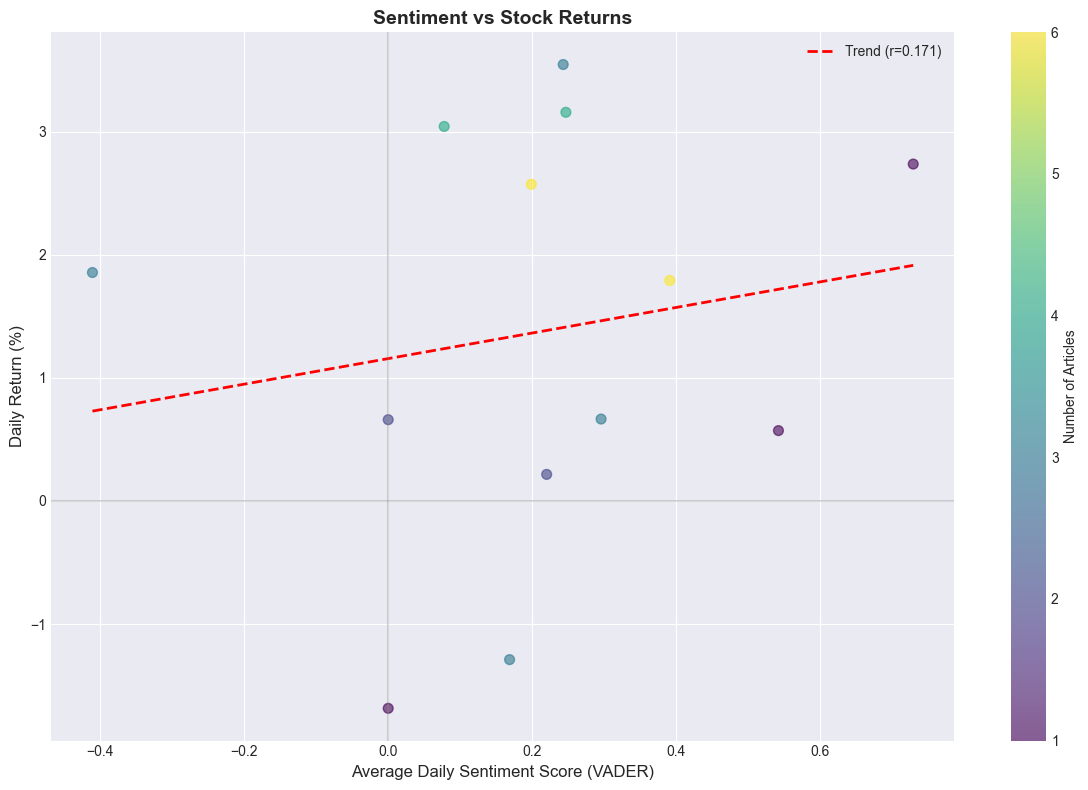

In [28]:
# Visualization: Sentiment vs Returns
if combined_df is not None and len(combined_df) > 0:
    # Scatter plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    scatter = ax.scatter(
        combined_df['avg_sentiment'], 
        combined_df['return'],
        c=combined_df['article_count'],
        cmap='viridis',
        alpha=0.6,
        s=50
    )
    
    # Add trend line
    z = np.polyfit(combined_df['avg_sentiment'], combined_df['return'], 1)
    p = np.poly1d(z)
    ax.plot(combined_df['avg_sentiment'].sort_values(), 
            p(combined_df['avg_sentiment'].sort_values()), 
            "r--", linewidth=2, label=f'Trend (r={correlation:.3f})')
    
    ax.set_xlabel('Average Daily Sentiment Score (VADER)', fontsize=12)
    ax.set_ylabel('Daily Return (%)', fontsize=12)
    ax.set_title('Sentiment vs Stock Returns', fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    ax.legend()
    
    cbar = plt.colorbar(scatter)
    cbar.set_label('Number of Articles', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('data/sentiment_vs_returns.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    

In [26]:
# Add sentiment_class to combined_df
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

combined_df['sentiment_class'] = combined_df['avg_sentiment'].apply(classify_sentiment)

print("✅ Added sentiment_class column")
print(f"\nDistribution:")
print(combined_df['sentiment_class'].value_counts())

✅ Added sentiment_class column

Distribution:
sentiment_class
Positive    10
Neutral      2
Negative     1
Name: count, dtype: int64


Average Returns by Sentiment:
sentiment_class
Positive    1.701090
Neutral    -0.512320
Negative    1.855992
Name: return, dtype: float64


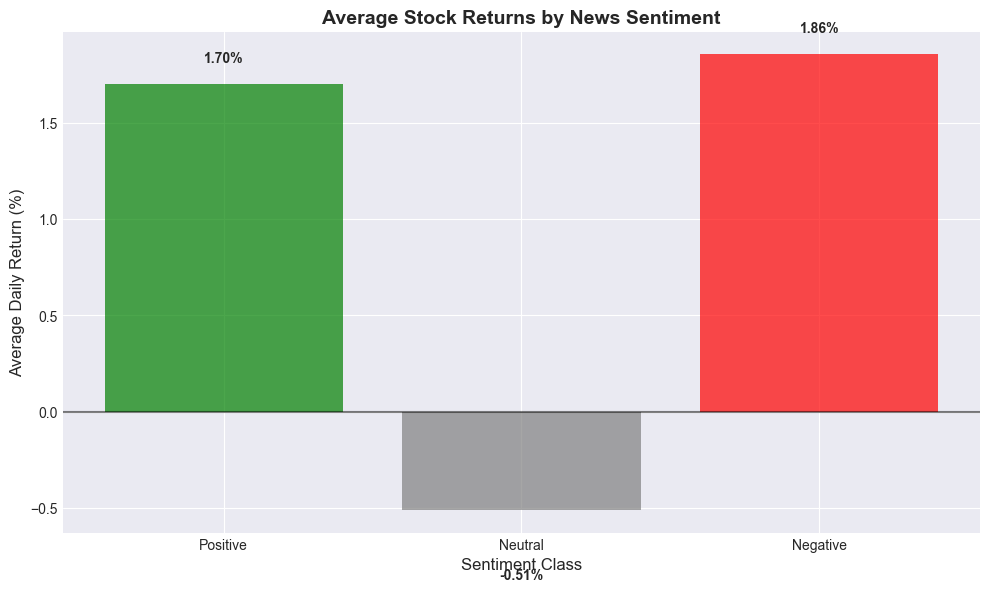

In [27]:
# Sentiment vs Returns Bar Chart
if combined_df is not None and len(combined_df) > 0:
    
    # Ensure sentiment_class exists
    if 'sentiment_class' not in combined_df.columns:
        def classify_sentiment(score):
            if score > 0.05:
                return 'Positive'
            elif score < -0.05:
                return 'Negative'
            else:
                return 'Neutral'
        combined_df['sentiment_class'] = combined_df['avg_sentiment'].apply(classify_sentiment)
    
    # Calculate average returns by sentiment
    sentiment_returns = combined_df.groupby('sentiment_class')['return'].mean()
    
    # Reindex to ensure correct order
    sentiment_returns = sentiment_returns.reindex(['Positive', 'Neutral', 'Negative'])
    
    print("Average Returns by Sentiment:")
    print(sentiment_returns)
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['green', 'gray', 'red']
    bars = ax.bar(sentiment_returns.index, sentiment_returns.values, color=colors, alpha=0.7)
    
    ax.set_xlabel('Sentiment Class', fontsize=12)
    ax.set_ylabel('Average Daily Return (%)', fontsize=12)
    ax.set_title('Average Stock Returns by News Sentiment', fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels on bars
    for bar, value in zip(bars, sentiment_returns.values):
        if not pd.isna(value):
            ax.text(bar.get_x() + bar.get_width()/2, value + (0.1 if value >= 0 else -0.3),
                    f'{value:.2f}%', ha='center', va='bottom' if value >= 0 else 'top', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

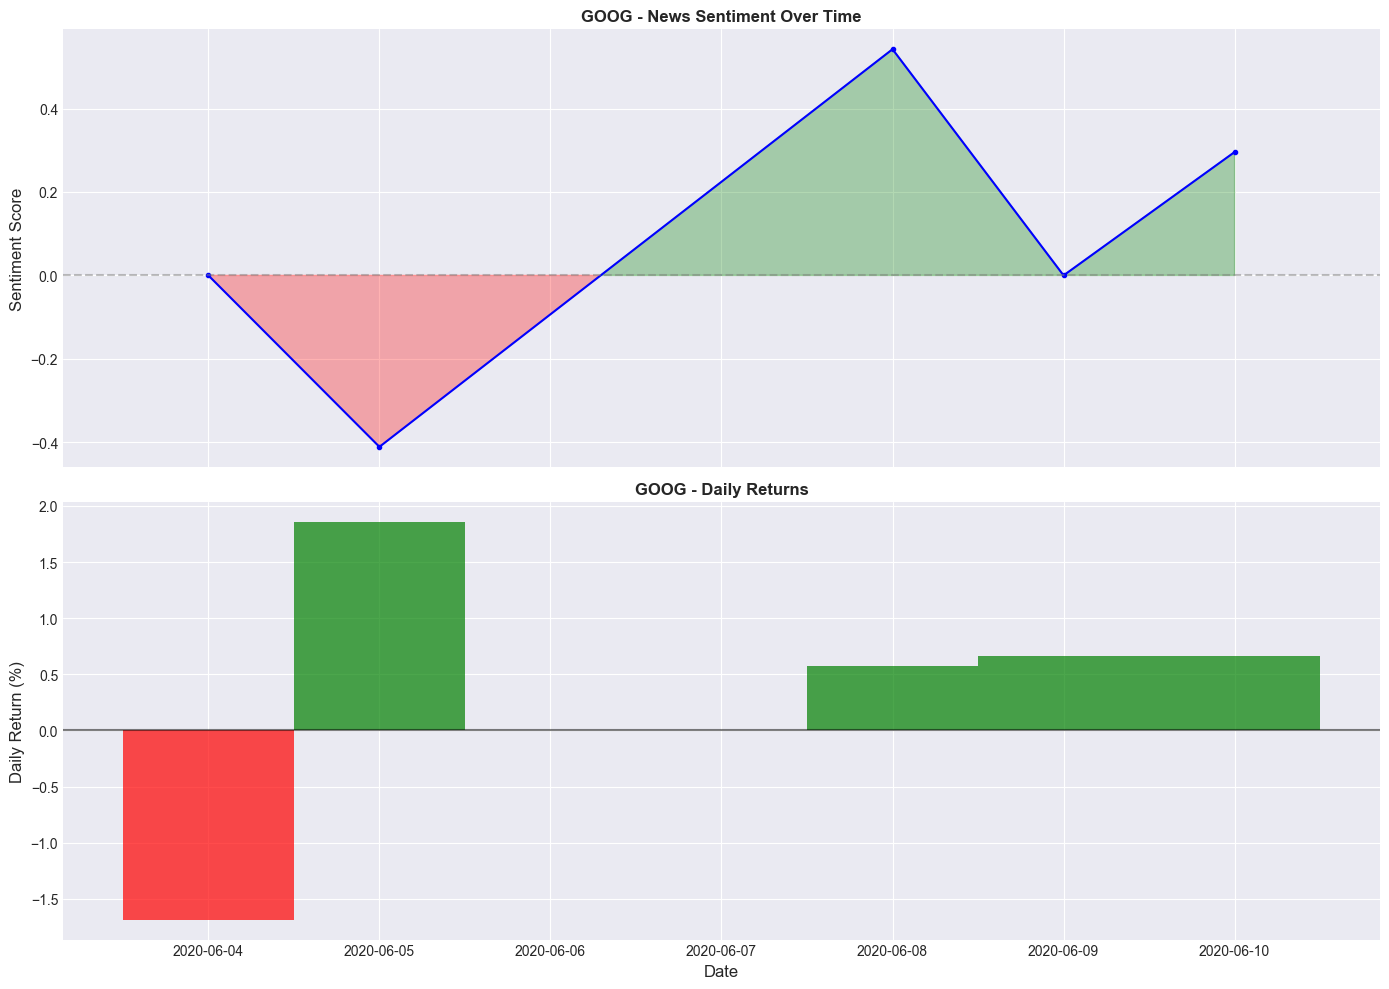

In [29]:
# Time Series Analysis
if combined_df is not None and len(combined_df) > 0:
    # Create time series plot for a specific stock
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Pick the stock with most data points
    stock_counts = combined_df['stock'].value_counts()
    top_stock = stock_counts.index[0]
    
    stock_subset = combined_df[combined_df['stock'] == top_stock].sort_values('date')
    
    # Plot 1: Sentiment over time
    axes[0].plot(stock_subset['date'], stock_subset['avg_sentiment'], 
                 color='blue', linewidth=1.5, marker='o', markersize=3)
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel('Sentiment Score', fontsize=12)
    axes[0].set_title(f'{top_stock} - News Sentiment Over Time', fontsize=12, fontweight='bold')
    axes[0].fill_between(stock_subset['date'], 0, stock_subset['avg_sentiment'], 
                          where=(stock_subset['avg_sentiment'] >= 0), 
                          color='green', alpha=0.3, interpolate=True)
    axes[0].fill_between(stock_subset['date'], 0, stock_subset['avg_sentiment'], 
                          where=(stock_subset['avg_sentiment'] <= 0), 
                          color='red', alpha=0.3, interpolate=True)
    
    # Plot 2: Returns over time
    axes[1].bar(stock_subset['date'], stock_subset['return'], 
                color=['green' if x >= 0 else 'red' for x in stock_subset['return']], 
                alpha=0.7, width=1)
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes[1].set_xlabel('Date', fontsize=12)
    axes[1].set_ylabel('Daily Return (%)', fontsize=12)
    axes[1].set_title(f'{top_stock} - Daily Returns', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('data/sentiment_returns_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()


In [30]:
# Investment Strategy Recommendations
print("\n" + "="*70)
print("INVESTMENT STRATEGY RECOMMENDATIONS")
print("="*70)

if combined_df is not None and len(combined_df) > 0:
    # Strategy 1: Sentiment-based trading
    print("\n📊 STRATEGY 1: Sentiment Momentum Strategy")
    print("-" * 50)
    
    # Calculate average return after positive vs negative sentiment
    pos_sentiment_returns = combined_df[combined_df['avg_sentiment'] > 0.05]['return'].mean()
    neg_sentiment_returns = combined_df[combined_df['avg_sentiment'] < -0.05]['return'].mean()
    neutral_returns = combined_df[(combined_df['avg_sentiment'] >= -0.05) & (combined_df['avg_sentiment'] <= 0.05)]['return'].mean()
    
    print(f"   Average return after POSITIVE sentiment: {pos_sentiment_returns:.3f}%")
    print(f"   Average return after NEGATIVE sentiment: {neg_sentiment_returns:.3f}%")
    print(f"   Average return after NEUTRAL sentiment: {neutral_returns:.3f}%")
    
    if pos_sentiment_returns > neg_sentiment_returns:
        print(f"\n   ✅ RECOMMENDATION: Go long on stocks with positive news sentiment")
        print(f"      Expected premium: {pos_sentiment_returns - neg_sentiment_returns:.3f}%")
    else:
        print(f"\n   ⚠️ Sentiment signal is contrarian - negative sentiment predicts positive returns")
    
    # Strategy 2: Stock-specific recommendations
    print("\n📊 STRATEGY 2: Stock-Specific Sentiment Signals")
    print("-" * 50)
    
    for stock in combined_df['stock'].unique():
        stock_data_subset = combined_df[combined_df['stock'] == stock]
        stock_corr, _ = pearsonr(stock_data_subset['avg_sentiment'], stock_data_subset['return'])
        stock_pos_return = stock_data_subset[stock_data_subset['avg_sentiment'] > 0.05]['return'].mean()
        
        print(f"\n   {stock}:")
        print(f"      Sentiment-Return Correlation: {stock_corr:.3f}")
        if stock_corr > 0.2:
            print(f"      ✅ Positive correlation - sentiment is predictive")
            print(f"      📈 When sentiment is positive, average return: {stock_pos_return:.3f}%")
        elif stock_corr < -0.2:
            print(f"      🔄 Negative correlation - contrarian signal")
        else:
            print(f"      ⚪ Weak correlation - sentiment not reliable for this stock")
    
    # Strategy 3: Combined approach
    print("\n📊 STRATEGY 3: Combined Technical + Sentiment Approach")
    print("-" * 50)
    print("   Recommended hybrid strategy:")
    print("   1. Use sentiment for entry signals (positive sentiment days)")
    print("   2. Use RSI for exit signals (sell when RSI > 70)")
    print("   3. Use MACD for trend confirmation")
    print("   4. Focus on stocks with correlation > 0.2")
    
    # Overall recommendation
    print("\n" + "="*70)
    print("🎯 OVERALL RECOMMENDATION")
    print("="*70)
    
    if correlation > 0.2 and p_value < 0.05:
        print("\n   ✅ News sentiment shows a statistically significant positive")
        print("      correlation with stock returns. This indicates that sentiment")
        print("      can be used as a predictive factor for price movements.")
        print("\n   📈 ACTIONABLE STRATEGY:")
        print("      - Monitor daily news sentiment for your watchlist stocks")
        print("      - Take long positions when sentiment score > 0.05")
        print("      - Take short positions or reduce exposure when sentiment < -0.05")
        print("      - Combine with technical indicators for confirmation")
    elif correlation < -0.2 and p_value < 0.05:
        print("\n   🔄 News sentiment shows significant negative correlation.")
        print("      This suggests a contrarian strategy may be effective.")
        print("\n   📈 ACTIONABLE STRATEGY:")
        print("      - Take long positions when sentiment is negative (oversold)")
        print("      - Take profits when sentiment becomes extremely positive")
    else:
        print("\n   ⚠️ Weak or non-significant correlation detected.")
        print("      Sentiment alone may not be sufficient for trading decisions.")
        print("\n   📈 ALTERNATIVE APPROACH:")
        print("      - Use sentiment as a secondary confirmation factor")
        print("      - Combine with technical indicators for higher confidence")
        print("      - Focus on specific stocks with higher individual correlations")
else:
    print("\n❌ Insufficient data to generate recommendations")
    print("   Please ensure sentiment and return data are properly aligned")



INVESTMENT STRATEGY RECOMMENDATIONS

📊 STRATEGY 1: Sentiment Momentum Strategy
--------------------------------------------------
   Average return after POSITIVE sentiment: 1.701%
   Average return after NEGATIVE sentiment: 1.856%
   Average return after NEUTRAL sentiment: -0.512%

   ⚠️ Sentiment signal is contrarian - negative sentiment predicts positive returns

📊 STRATEGY 2: Stock-Specific Sentiment Signals
--------------------------------------------------

   AAPL:
      Sentiment-Return Correlation: 1.000
      ✅ Positive correlation - sentiment is predictive
      📈 When sentiment is positive, average return: 2.865%

   AMZN:
      Sentiment-Return Correlation: -1.000
      🔄 Negative correlation - contrarian signal

   GOOG:
      Sentiment-Return Correlation: -0.234
      🔄 Negative correlation - contrarian signal

   NVDA:
      Sentiment-Return Correlation: 0.523
      ✅ Positive correlation - sentiment is predictive
      📈 When sentiment is positive, average return: 1.3

In [31]:
# Limitations and Future Improvements
print("\n" + "="*70)
print("LIMITATIONS AND FUTURE IMPROVEMENTS")
print("="*70)

print("\n📌 Current Limitations:")
print("   1. Same-day correlation only - no lag analysis")
print("   2. Simple average sentiment aggregation")
print("   3. No control for market-wide factors (e.g., overall market movement)")
print("   4. Limited to stocks with available price data")
print("   5. Potential confounding from multiple news articles per day")
print("   6. VADER may not capture financial-specific sentiment nuances")

print("\n🚀 Potential Improvements for Future Work:")
print("   1. Lag analysis (sentiment effect on next 1-5 days)")
print("   2. Weighted sentiment based on publisher credibility")
print("   3. Incorporate news volume as additional signal")
print("   4. Machine learning models (Random Forest, LSTM)")
print("   5. Event study around major news announcements")
print("   6. Sector-specific sentiment models")
print("   7. Real-time sentiment pipeline implementation")



LIMITATIONS AND FUTURE IMPROVEMENTS

📌 Current Limitations:
   1. Same-day correlation only - no lag analysis
   2. Simple average sentiment aggregation
   3. No control for market-wide factors (e.g., overall market movement)
   4. Limited to stocks with available price data
   5. Potential confounding from multiple news articles per day
   6. VADER may not capture financial-specific sentiment nuances

🚀 Potential Improvements for Future Work:
   1. Lag analysis (sentiment effect on next 1-5 days)
   2. Weighted sentiment based on publisher credibility
   3. Incorporate news volume as additional signal
   4. Machine learning models (Random Forest, LSTM)
   5. Event study around major news announcements
   6. Sector-specific sentiment models
   7. Real-time sentiment pipeline implementation


In [32]:
# Summary Report
print("\n" + "="*70)
print("TASK 3: SENTIMENT & CORRELATION - SUMMARY")
print("="*70)

if news_df is not None:
    print(f"\n📰 News Data:")
    print(f"   Total articles analyzed: {len(news_df)}")
    print(f"   Positive sentiment: {len(news_df[news_df['vader_score'] > 0.05])} ({len(news_df[news_df['vader_score'] > 0.05])/len(news_df)*100:.1f}%)")
    print(f"   Negative sentiment: {len(news_df[news_df['vader_score'] < -0.05])} ({len(news_df[news_df['vader_score'] < -0.05])/len(news_df)*100:.1f}%)")
    print(f"   Neutral sentiment: {len(news_df[(news_df['vader_score'] >= -0.05) & (news_df['vader_score'] <= 0.05)])} ({len(news_df[(news_df['vader_score'] >= -0.05) & (news_df['vader_score'] <= 0.05)])/len(news_df)*100:.1f}%)")

if combined_df is not None and len(combined_df) > 0:
    print(f"\n📈 Correlation Analysis:")
    print(f"   Sample size: {len(combined_df)} stock-day pairs")
    print(f"   Pearson correlation: {correlation:.4f}")
    print(f"   P-value: {p_value:.4f}")
    print(f"   Statistical significance: {'Yes' if p_value < 0.05 else 'No'}")

print("\n" + "="*70)
print("✅ Task 3 Complete!")
print("="*70)


TASK 3: SENTIMENT & CORRELATION - SUMMARY

📰 News Data:
   Total articles analyzed: 40
   Positive sentiment: 22 (55.0%)
   Negative sentiment: 3 (7.5%)
   Neutral sentiment: 15 (37.5%)

📈 Correlation Analysis:
   Sample size: 13 stock-day pairs
   Pearson correlation: 0.1709
   P-value: 0.5767
   Statistical significance: No

✅ Task 3 Complete!
